In [123]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("rezultati.csv")

In [ ]:
medalje = pd.crosstab(
    df["Država"], 
    df["Medalja"]
    )[["G", "S", "B", "HM"]]

medalje.sort_values(
    by=["G", "S", "B"],
    ascending=False
).head(20)

medalja,G,S,B,HM
drzava,,,,
People's Republic of China,197,37,6,0
United States of America,160,122,31,1
Russian Federation,110,64,12,0
Republic of Korea,102,87,28,8
Hungary,91,178,121,14
Romania,89,164,114,13
Union of Soviet Socialist Republics,77,67,45,2
Vietnam,73,123,87,3
United Kingdom,61,126,136,18


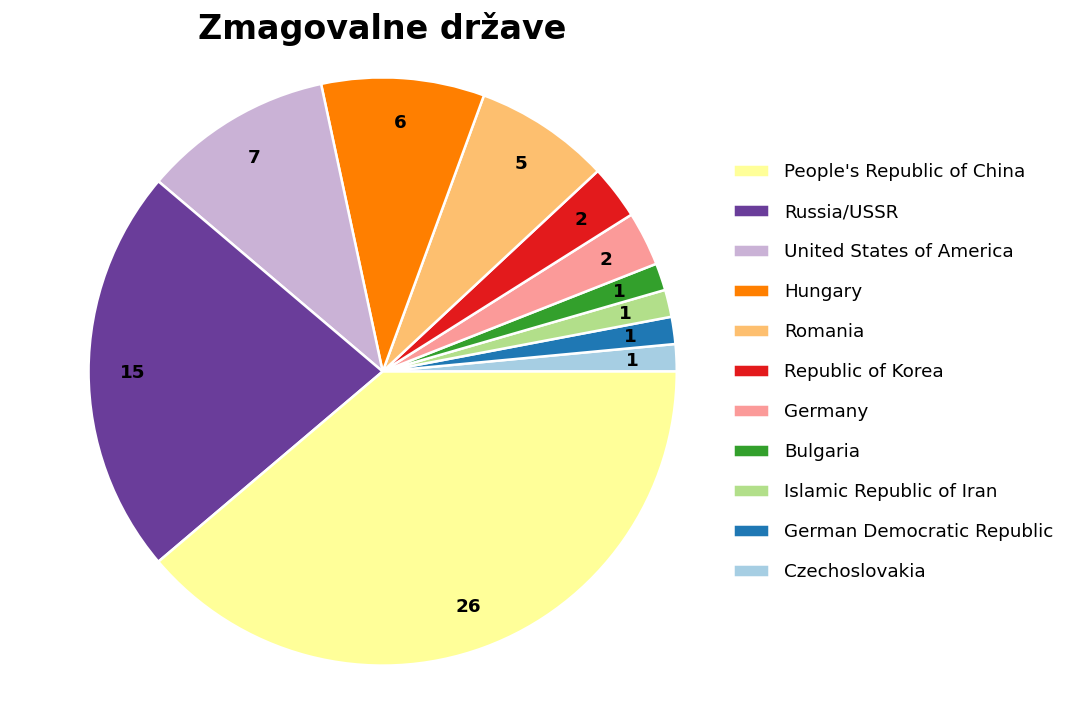

In [ ]:
from collections import defaultdict

preimenovanje = {
    "Russian Federation" : "Russia/USSR",
    "Union of Soviet Socialist Republics" : "Russia/USSR"
}

df_all = df.copy()
df_all["Država_skupina"] = df_all["Država"].replace(preimenovanje)
df_all["Skupno" ] = pd.to_numeric(df_all["Skupno"], errors="coerce").fillna(0)

tocke_po_letih = df_all.groupby(["Leto", "Država_skupina"])["Skupno"].sum().reset_index()

zmage = defaultdict(int)

for leto, skupina in tocke_po_letih.groupby("Leto"):
    skupina_je = skupina[skupina["Skupno"] > 0]
    if skupina_je.empty:
        continue

    najboljsi = skupina_je.loc[skupina_je["Skupno"].idxmax(), "Država_skupina"]
    zmage[najboljsi] += 1

urejeno = sorted(zmage.items(), key=lambda x: x[1], reverse=False)
labels = [drzava for drzava, _ in urejeno]
velikosti = [stevilo for _, stevilo in urejeno]

barve = plt.cm.Paired.colors

fig, ax = plt.subplots(figsize=(9, 6), dpi=120)

wedges, texts, autotexts = ax.pie(
    velikosti,
    labels=None,
    autopct=lambda pct: f"{round(pct/100 * sum(velikosti))}",
    startangle=0,
    colors=barve,
    pctdistance=0.85,
    textprops={"fontsize": 11, "color": "black", "weight": "bold"},
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)

ax.legend(
    wedges[::-1],
    labels[::-1],
    labelspacing=1.2,
    loc="center left",
    bbox_to_anchor=(0.95, 0.5),
    fontsize=11,
    frameon=False
)


ax.set_title("Zmagovalne države", fontsize=20, weight="bold")
ax.axis("equal")
plt.tight_layout()
plt.show()

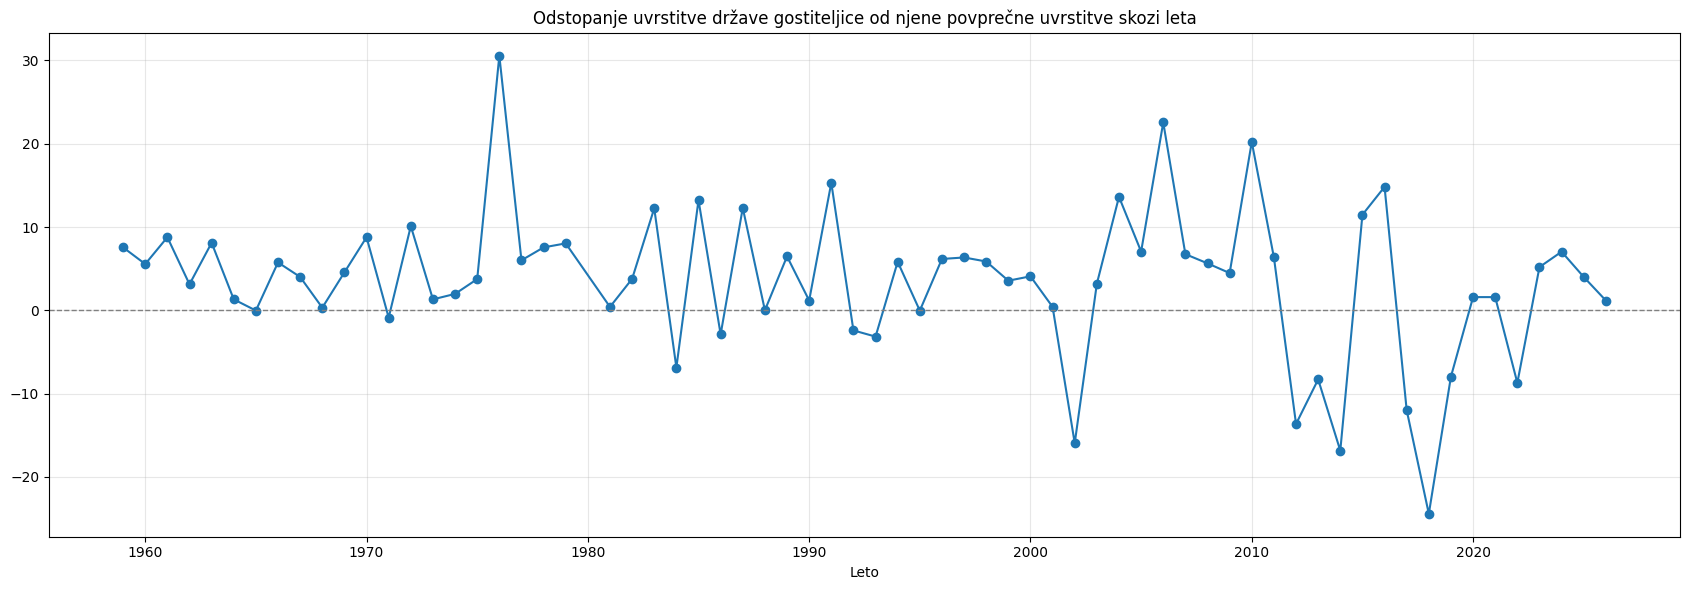

In [ ]:
povp_mesto = (
    df
    .groupby(["Leto", "Država"])["Mesto"]
    .mean()
    .reset_index()
    .rename(columns={"Mesto": "Povprečno_mesto"})
)

# 2. Relativna uvrstitev države med vsemi sodelujočimi tisto leto
povp_mesto["Relativna_uvrstitev"] = (
    povp_mesto
    .groupby("Leto")["Povprečno_mesto"]
    .rank(method="min")
)

# 3. Povprečna relativna uvrstitev vsake države skozi vsa leta
povp_relativna = (
    povp_mesto
    .groupby("Država")["Relativna_uvrstitev"]
    .mean()
    .reset_index()
    .rename(columns={"Relativna_uvrstitev": "Povprečna_relativna_uvrstitev"})
)

# 4. Za vsako leto poišči gostiteljico - preimenuj TAKOJ v isti vrstici
gostitelji = (
    df[["Leto", "Gostiteljica"]]
    .drop_duplicates(subset="leto")
    .rename(columns={"Gostiteljica": "Država"})
)

# 5. Poveži: relativna uvrstitev gostiteljice tisto leto
gostitelji_uvrstitev = gostitelji.merge(
    povp_mesto[["Leto", "Država", "Povprečno_mesto", "Relativna_uvrstitev"]],
    on=["Leto", "Država"],
    how="left"
)

# 6. Poveži s povprečno relativno uvrstitvijo te države skozi vsa leta
gostitelji_uvrstitev = gostitelji_uvrstitev.merge(
    povp_relativna,
    on="Država",
    how="left"
)

# 7. Odstopanje
gostitelji_uvrstitev["Odstopanje"] = (
    gostitelji_uvrstitev["Povprečna_relativna_uvrstitev"] - gostitelji_uvrstitev["Relativna_uvrstitev"]
)

gostitelji_uvrstitev = gostitelji_uvrstitev.sort_values("Leto")

plt.figure(figsize=(17, 6))
plt.plot(gostitelji_uvrstitev["Leto"], gostitelji_uvrstitev["Odstopanje"], marker="o")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Leto")
plt.title("Odstopanje uvrstitve države gostiteljice od njene povprečne uvrstitve skozi leta")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [184]:
df.groupby("ime")["skupno"].sum().sort_values(ascending=False).head(10)

ime
David        2644
Ivan         2077
Martin       2042
Daniel       1951
Andrei       1636
Jan          1587
Peter        1569
Vladimir     1539
Michael      1414
Alexander    1385
Name: skupno, dtype: int64